In [1]:

from scipy.signal import butter, lfilter
import scipy.io
import numpy as np
import pandas as pd
import wfdb
import matplotlib.pyplot as plt
import ast
 
import sys
sys.path.insert(1, '../src')

from data_processing import bandpass_filter, derivative_filter

import neurokit2 as nk

In [2]:
from data_loader import load_raw_data

path = "../data/raw/ptb-xl-1.0.3/"
sampling_rate = 100

Y = pd.read_csv(path + "ptbxl_database.csv", index_col='ecg_id')
Y.scp_codes = Y.scp_codes.apply(lambda x: ast.literal_eval(x))

X = load_raw_data()

100%|██████████| 21799/21799 [09:26<00:00, 38.50it/s]


In [3]:
from data_loader import cleaned_data
data = cleaned_data(X)


In [4]:
np.asarray(data).shape

(21799, 1000, 12)

In [5]:

# def load_raw_data(df, sampling_rate, path):
#     if sampling_rate == 100:
#         data = [wfdb.rdsamp(path+f) for f in df.filename_lr]
#     else:
#         data = [wfdb.rdsamp(path+f) for f in df.filename_hr]
#     data = np.array([signal for signal, meta in data])
#     return data

# print("yo")

In [6]:
Y.head() 

,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,sinusrhythmus normales ekg,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,sinusrhythmus normales ekg,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


In [7]:
missing = Y.isnull().sum()
missing_percentage = (missing / len(Y)) * 100

missing_values = pd.DataFrame(
    {
        'Missing Values': missing,
        'Percentage': missing_percentage.round(2)
    }
)
# print(missing)
# print(missing_percentage)
missing_values

,Missing Values,Percentage
patient_id,0,0.00
age,0,0.00
sex,0,0.00
height,14825,68.01
weight,12378,56.78
nurse,1473,6.76
site,17,0.08
device,0,0.00
recording_date,0,0.00
report,0,0.00


In [8]:
scp_statements = pd.read_csv(path + "scp_statements.csv")
scp_statements.rename(columns={'Unnamed: 0': 'code'}, inplace=True)
scp_statements.head()

,code,description,diagnostic,form,rhythm,diagnostic_class,diagnostic_subclass,Statement Category,SCP-ECG Statement Description,AHA code,aECG REFID,CDISC Code,DICOM Code
0,NDT,non-diagnostic T abnormalities,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,non-diagnostic T abnormalities,NaN,NaN,NaN,NaN
1,NST_,non-specific ST changes,1.0,1.0,NaN,STTC,NST_,Basic roots for coding ST-T changes and abnorm...,non-specific ST changes,145.0,MDC_ECG_RHY_STHILOST,NaN,NaN
2,DIG,digitalis-effect,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,suggests digitalis-effect,205.0,NaN,NaN,NaN
3,LNGQT,long QT-interval,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,long QT-interval,148.0,NaN,NaN,NaN
4,NORM,normal ECG,1.0,NaN,NaN,NORM,NORM,Normal/abnormal,normal ECG,1.0,NaN,NaN,F-000B7


In [9]:
print(Y['scp_codes'].iloc[0])
code_counts = {}
for code in scp_statements['code']: 
    code_counts[code] = 0
    
for scp_codes in Y['scp_codes']:
    for code in scp_codes:
        if scp_codes[code] > 0:
            code_counts[code] += 1
print(sum(code_counts.values()))
sorted(code_counts.items(), key=lambda x: x[1], reverse=True)[:20]
        

{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}
32015


[('NORM', 9514),
 ('IMI', 2676),
 ('ASMI', 2357),
 ('LVH', 2132),
 ('NDT', 1825),
 ('LAFB', 1623),
 ('ISC_', 1272),
 ('IRBBB', 1118),
 ('PVC', 1027),
 ('1AVB', 793),
 ('IVCD', 787),
 ('ISCAL', 659),
 ('NST_', 559),
 ('CRBBB', 541),
 ('CLBBB', 536),
 ('ILMI', 478),
 ('LAO/LAE', 426),
 ('AMI', 353),
 ('ALMI', 288),
 ('PACE', 287)]

In [10]:
print(X[:5][:5])


[[[-1.190e-01 -5.500e-02  6.400e-02 ... -2.600e-02 -3.900e-02 -7.900e-02]
  [-1.160e-01 -5.100e-02  6.500e-02 ... -3.100e-02 -3.400e-02 -7.400e-02]
  [-1.200e-01 -4.400e-02  7.600e-02 ... -2.800e-02 -2.900e-02 -6.900e-02]
  ...
  [ 6.900e-02  0.000e+00 -6.900e-02 ...  2.400e-02 -4.100e-02 -5.800e-02]
  [ 8.600e-02  4.000e-03 -8.100e-02 ...  2.420e-01 -4.600e-02 -9.800e-02]
  [ 2.200e-02 -3.100e-02 -5.400e-02 ...  1.430e-01 -3.500e-02 -1.200e-01]]

 [[ 4.000e-03  1.380e-01  1.340e-01 ...  1.920e-01  8.300e-02  8.800e-02]
  [-2.000e-02  1.160e-01  1.360e-01 ...  1.560e-01  5.700e-02  6.300e-02]
  [-5.300e-02  9.200e-02  1.450e-01 ...  1.070e-01  1.300e-02  2.200e-02]
  ...
  [ 1.210e-01  3.980e-01  2.770e-01 ... -1.065e+00 -4.920e-01 -1.560e-01]
  [-3.260e-01  5.700e-02  3.830e-01 ... -2.800e-01 -1.750e-01 -7.100e-02]
  [-3.480e-01 -5.600e-02  2.920e-01 ... -3.080e-01 -2.310e-01 -1.450e-01]]

 [[-2.900e-02 -7.900e-02 -4.900e-02 ... -1.030e-01 -7.600e-02 -6.600e-02]
  [-3.500e-02 -7.000e-

In [11]:

lowcut = 0.5
highcut = 24.0
sampling_rate = 100

flattened_signal = X[0].flatten()
# print(flattened_signal.shape)

filtered_signal = bandpass_filter(flattened_signal, lowcut, highcut, sampling_rate)

In [12]:
reshaped_data = filtered_signal.reshape(1000, 12)

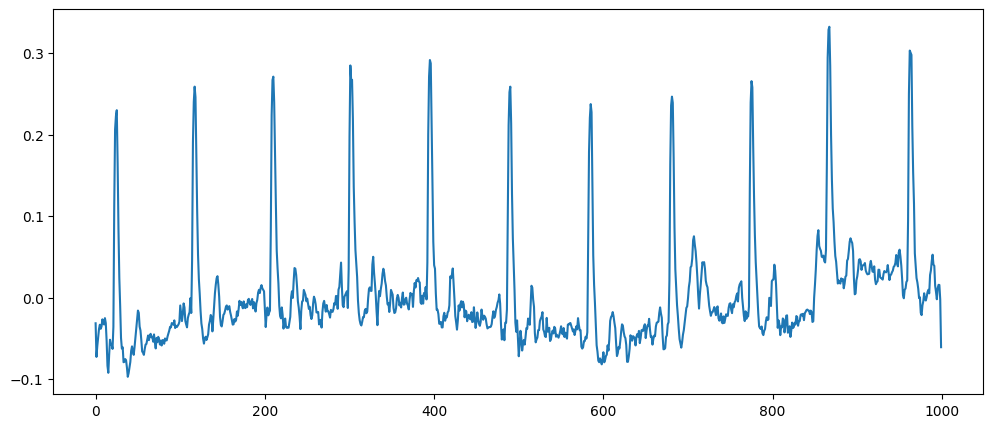

In [13]:

plt.figure(figsize=(12, 5))
plt.plot(reshaped_data[:, 0])

In [14]:
print(X.shape)
print(X[0].shape)
print(reshaped_data.shape)

(21799, 1000, 12)
(1000, 12)
(1000, 12)


In [15]:
len(X)

21799

In [16]:
cleaned = [0] * len(X)
for i in range(len(X)):
    flattened_signal = X[i].flatten()
    filtered_signal = bandpass_filter(flattened_signal, lowcut, highcut, sampling_rate)
    reshaped_data = filtered_signal.reshape(1000, 12)
    cleaned[i] = reshaped_data

    

In [17]:
np.shape(cleaned)

(21799, 1000, 12)

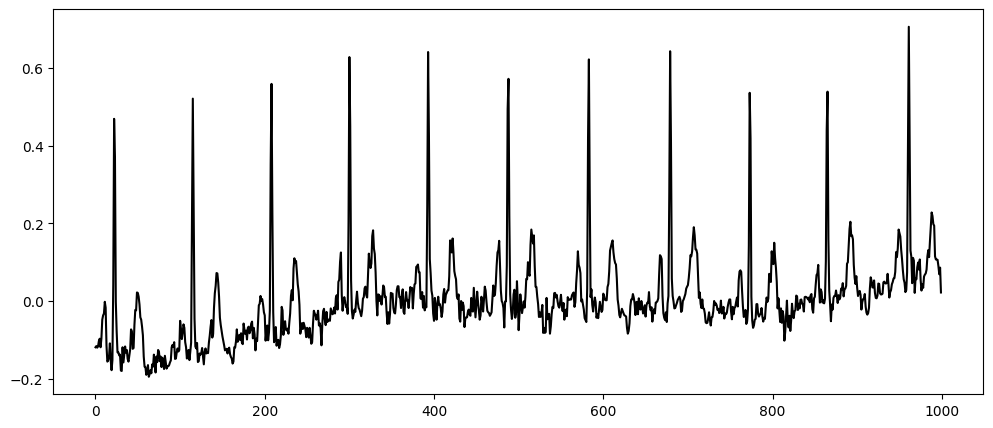

In [18]:
plt.figure(figsize=(12, 5))
plt.plot(X[0][:,0], color = "black")

plt.show()

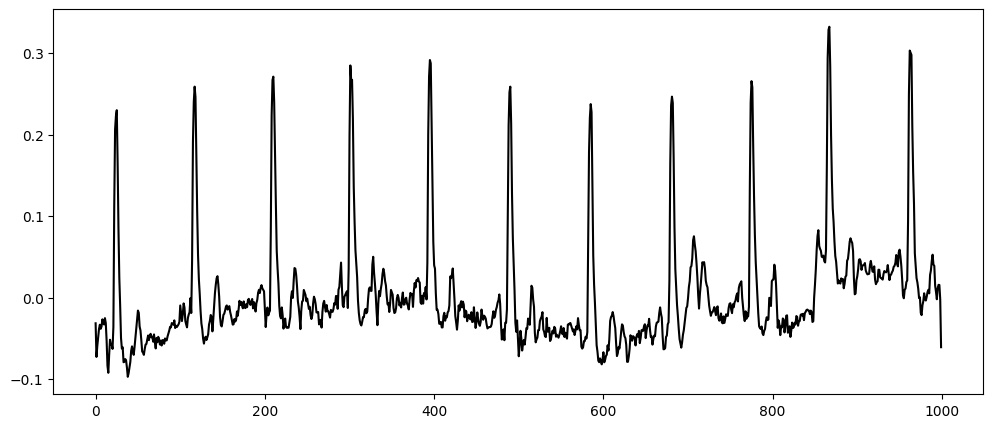

In [19]:
plt.figure(figsize=(12, 5))
plt.plot(cleaned[0][:,0], color = "black")
plt.show()

In [20]:
der = derivative_filter(cleaned[0][:,0])

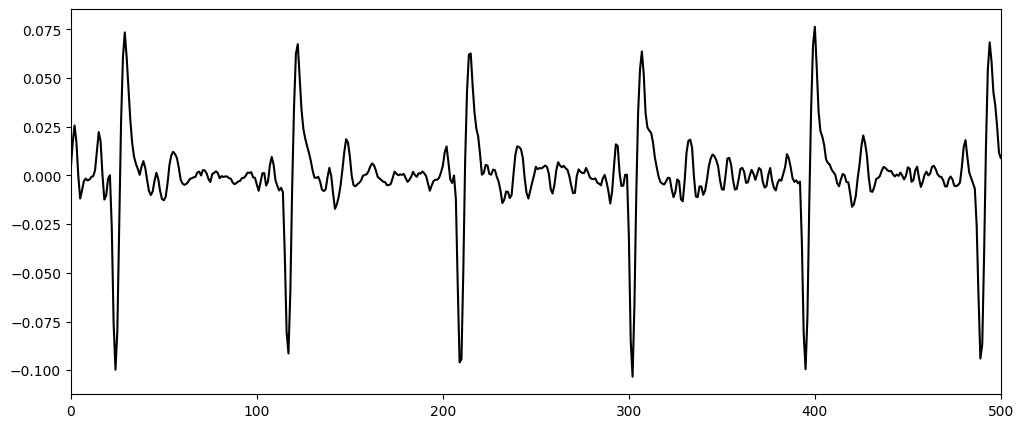

In [21]:
plt.figure(figsize=(12, 5))
plt.plot(der, color = "black")
plt.xlim(0, 500)
plt.show()

In [22]:
squared_signal = der ** 2 

In [23]:
def moving_window(signal, fs = 100, window_ms = 150):
    window_size = int((window_ms / 1000) * fs) # 15 data points 150/1000*100
    window = np.ones(window_size) / window_size
    return np.convolve(signal, window)

    

In [24]:
window_signal = moving_window(squared_signal)

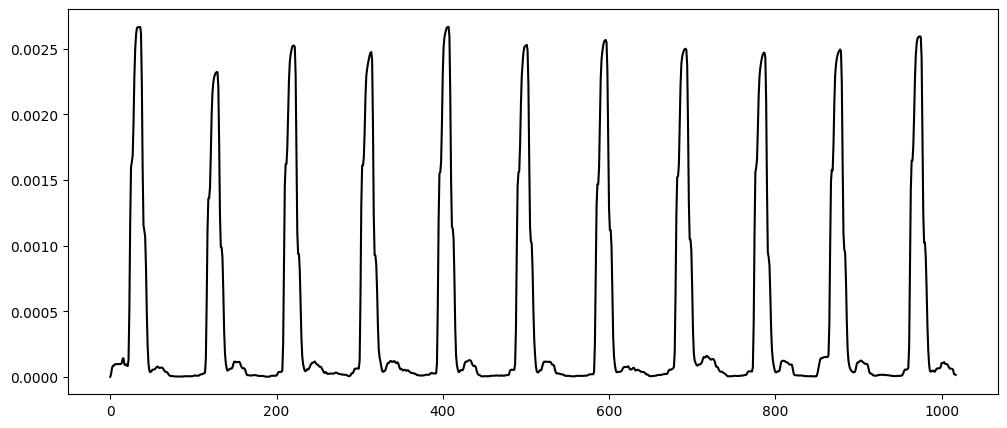

In [25]:
plt.figure(figsize=(12, 5))
plt.plot(window_signal, color = "black")
plt.show()

In [26]:
def manual_Rpeaks(signal, fs = 100):
    threshold = np.mean((signal) + np.max(signal)) / 2
    min_distance = round(fs * 0.2)
    
    peaks = []
    length = len(signal)
    
    for i in range(1, length - 1):
        if signal[i] > signal[i-1] and signal[i] >  signal[i+1] and signal[i] > threshold and (not peaks or i - peaks[-1] >= min_distance): 
            peaks.append(i)
            
    return np.array(peaks)



In [27]:
peaks_1 = manual_Rpeaks(window_signal)
peaks_2 = manual_Rpeaks(cleaned[0][:,0])
print(peaks_1)
print(peaks_2)

[ 33 128 221 314 407 501 596 692 787 868 964]
[ 25 117 210 301 395 490 585 681 775 867 962]


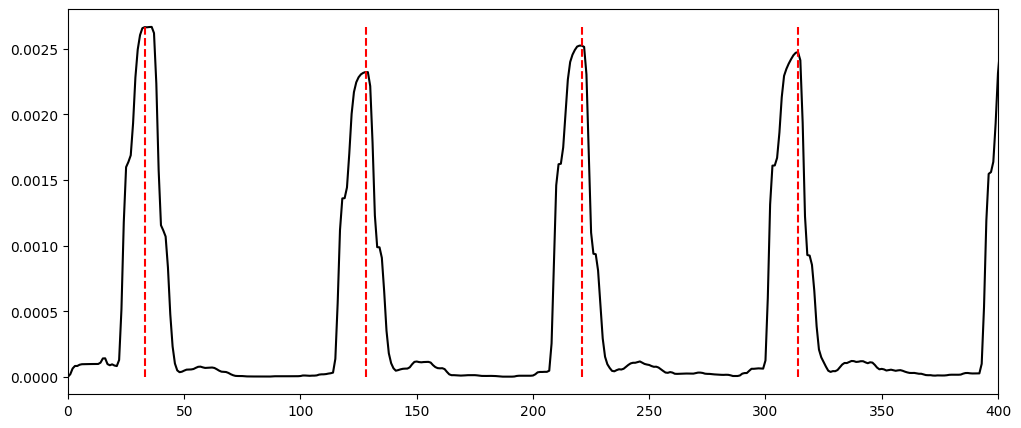

In [28]:
plt.figure(figsize=(12, 5))
plt.plot(window_signal, color = "black")
plt.vlines(peaks_1, ymin = min(window_signal), ymax= max(window_signal), color = "red", linestyle = '--')
plt.xlim(0, 400)
plt.show()

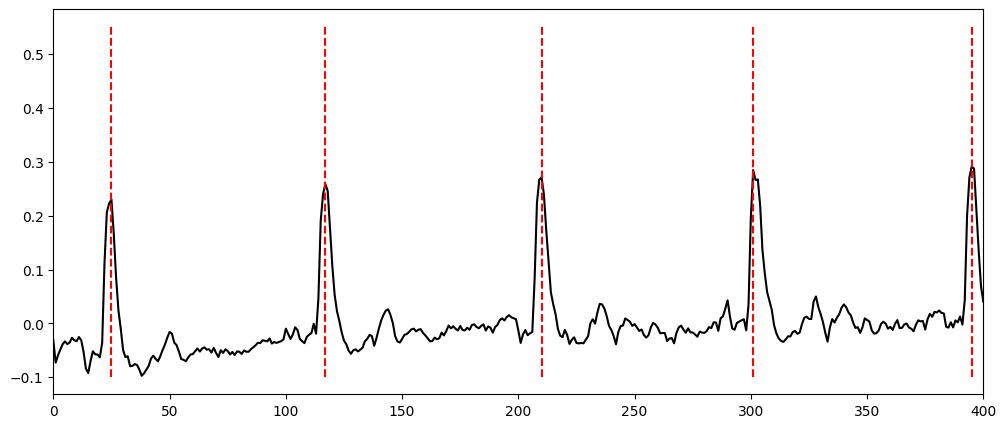

In [29]:
plt.figure(figsize=(12, 5))
plt.plot(cleaned[0][:,0], color = "black")
plt.vlines(peaks_2, ymin = min(reshaped_data[:,0]), ymax= max(reshaped_data[:,0]), color = "red", linestyle = '--')
plt.xlim(0, 400)
plt.show()

[ 25 117 210 301 395 490 585 681 775 867 962]


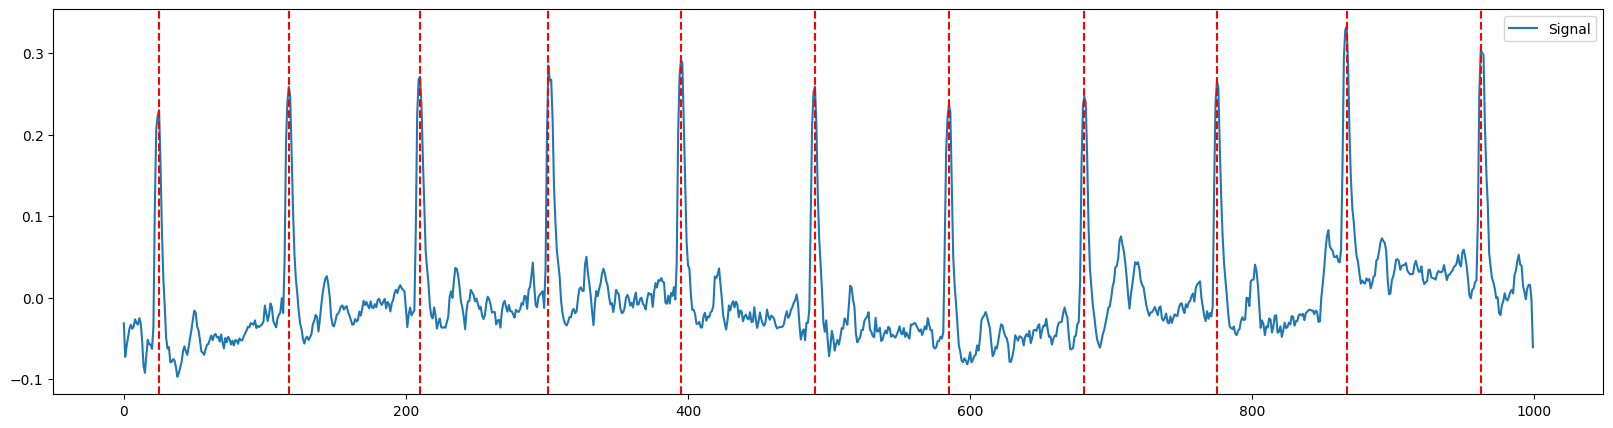

In [30]:
plt.rcParams['figure.figsize'] = [20, 5]
ecg_signal = cleaned[0][:,0]
padded_signal = np.pad(ecg_signal,(100, 0), 'edge')
# plt.plot(padded_signal[: 3 * 100], color = "black")

_, rpeaks = nk.ecg_peaks(padded_signal, sampling_rate=100,)
rpeaks["ECG_R_Peaks"] = rpeaks["ECG_R_Peaks"] - 100
print(rpeaks["ECG_R_Peaks"])
plot = nk.events_plot(rpeaks["ECG_R_Peaks"],  padded_signal[100:])


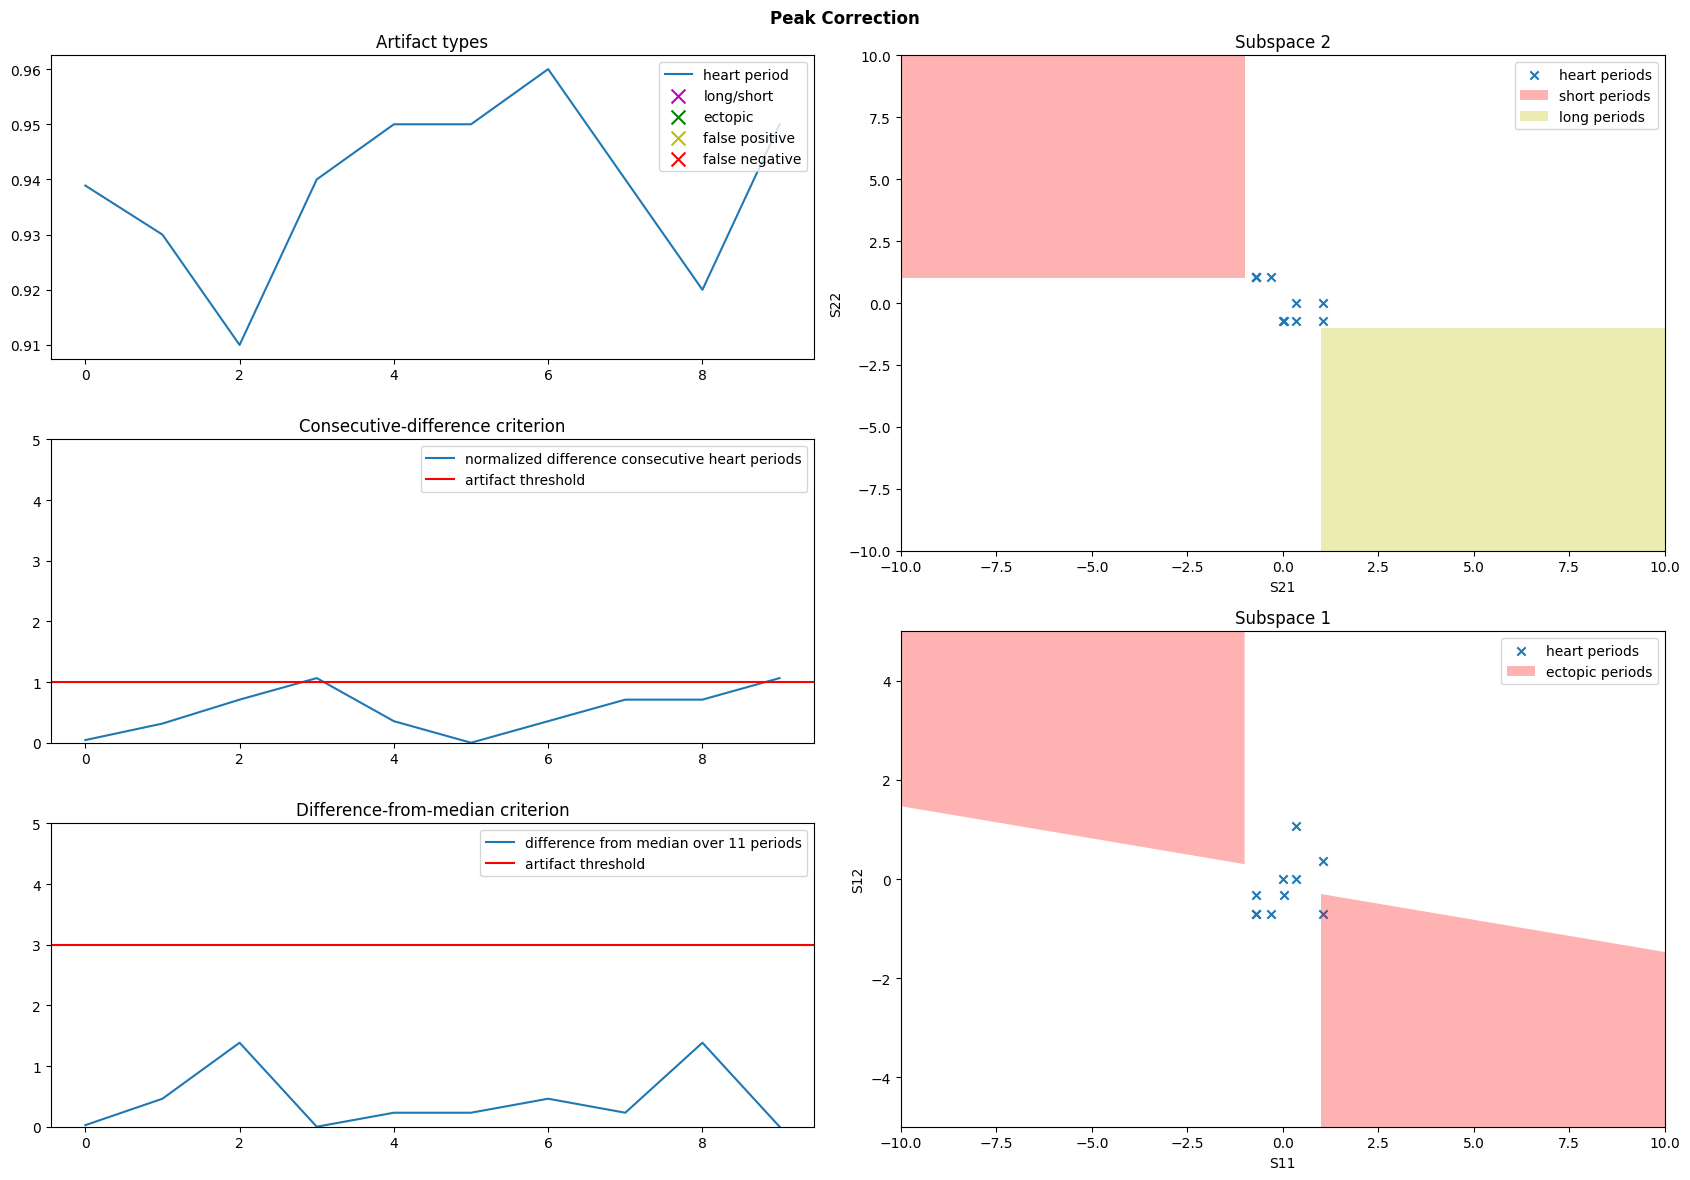

In [31]:
peak = nk.ecg_findpeaks(ecg_signal, sampling_rate=100)
f = nk.signal_fixpeaks(peak, sampling_rate=100, show=True)

In [32]:
np.shape(cleaned)

(21799, 1000, 12)

In [33]:
pads = np.empty((len(X), len(X[0])+100, len(X[0][0])))
for i in range(len(X)):
        for j in range(len(X[0][0])):
            signal = cleaned[i][:,j]
            pads[i][:,j] = np.pad(signal,(100, 0), 'edge')
            

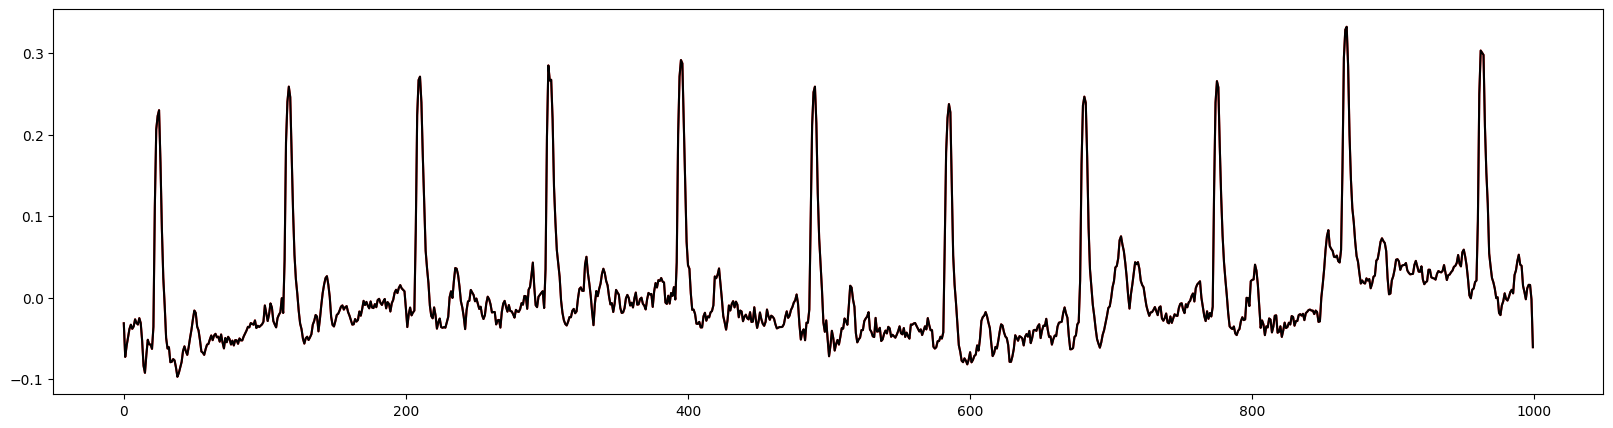

In [34]:
plt.plot(cleaned[0][:,0], color = "red")
plt.plot(pads[0][100:,0], color = "black")

[ 25 117 210 301 395 490 585 681 775 867 962]


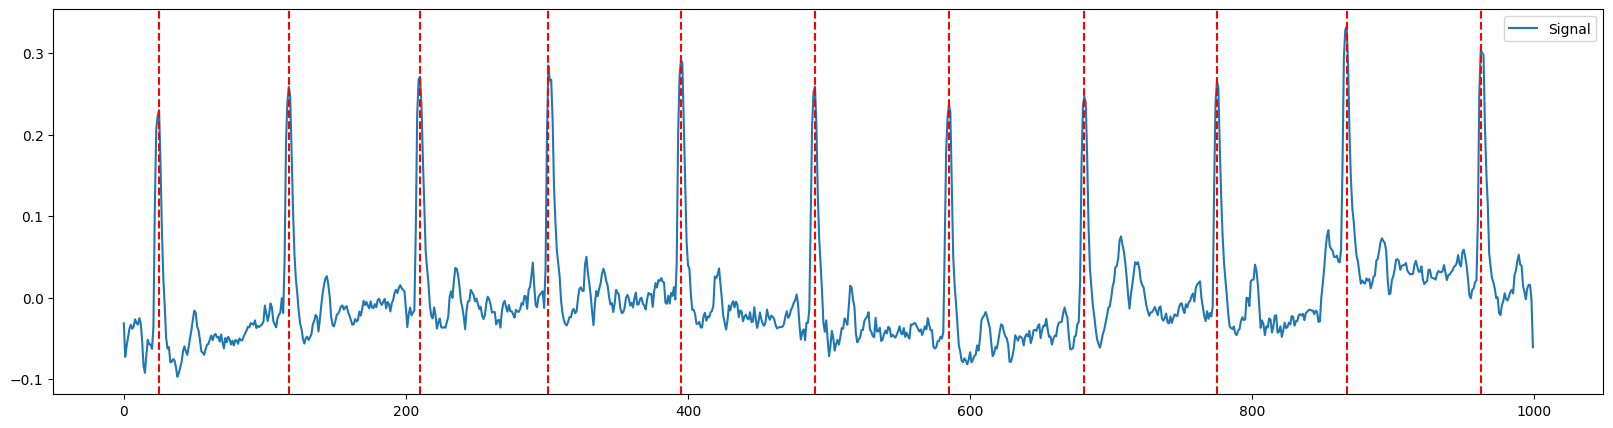

In [35]:
np.shape(pads)
plt.rcParams['figure.figsize'] = [20, 5]
_, rpeaks = nk.ecg_peaks(pads[0][:,0], sampling_rate=100,)
rpeaks["ECG_R_Peaks"] = rpeaks["ECG_R_Peaks"]-100
print(rpeaks["ECG_R_Peaks"])
plot = nk.events_plot(rpeaks["ECG_R_Peaks"], cleaned[0][:,0])



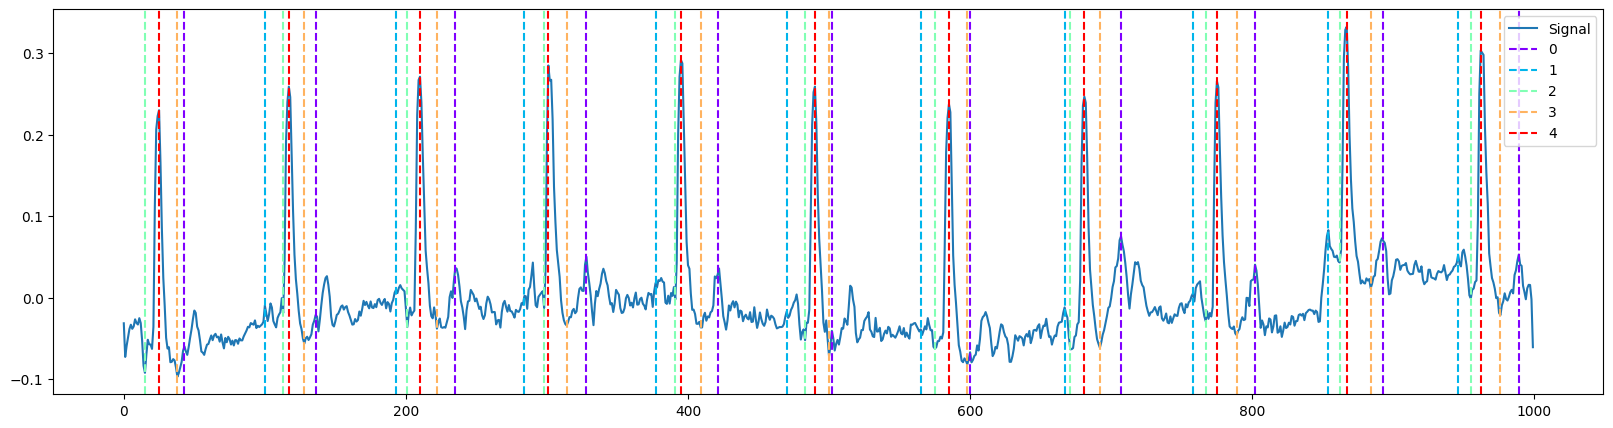

In [36]:
# Delineate the ECG signal
_, waves_peak = nk.ecg_delineate(cleaned[0][:,0], rpeaks, sampling_rate=100)

plot = nk.events_plot(
    [
        
        waves_peak["ECG_T_Peaks"],
        waves_peak["ECG_P_Peaks"],
        waves_peak["ECG_Q_Peaks"],
        waves_peak["ECG_S_Peaks"],
        rpeaks["ECG_R_Peaks"],
        
    ],
    ecg_signal,
)

In [37]:
waves_peak

{'ECG_P_Peaks': [nan, 100, 193, 284, 377, 470, 565, 667, 758, 854, 946],
 'ECG_P_Onsets': [nan, 98, 189, 283, 375, 467, 564, 665, 754, 848, 945],
 'ECG_P_Offsets': [nan, 101, 193, 286, 378, 471, 566, 672, 759, 856, 948],
 'ECG_Q_Peaks': [np.int64(15),
  np.int64(113),
  np.int64(201),
  np.int64(298),
  np.int64(391),
  np.int64(483),
  np.int64(575),
  np.int64(671),
  np.int64(767),
  np.int64(862),
  np.int64(955)],
 'ECG_R_Onsets': [nan, 112, 199, 297, 390, 482, 573, 669, 763, 860, 951],
 'ECG_R_Offsets': [28, 122, 215, 302, 400, 494, 590, 688, 782, 872, 967],
 'ECG_S_Peaks': [np.int64(38),
  np.int64(128),
  np.int64(222),
  np.int64(314),
  np.int64(409),
  np.int64(500),
  np.int64(598),
  np.int64(692),
  np.int64(789),
  np.int64(884),
  np.int64(976)],
 'ECG_T_Peaks': [43, 136, 235, 328, 421, 502, 600, 707, 802, 893, 989],
 'ECG_T_Onsets': [nan, 132, 233, 326, 420, 500, 599, 705, 801, 890, 987],
 'ECG_T_Offsets': [44, 138, 241, 333, 426, 504, 601, 713, 806, 898, 994]}